In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings. filterwarnings('ignore')
from sklearn.preprocessing import LabelEncoder , StandardScaler
from sklearn.model_selection import train_test_split
from sklearn. linear_model import Perceptron


from sklearn.metrics import accuracy_score, classification_report,confusion_matrix

from tensorflow.keras.models import Sequential # pyright: ignore[reportMissingImports]

from tensorflow.keras.layers import Dense # type: ignore
from tensorflow.keras.layers import Conv2D # type: ignore
from tensorflow.keras.layers import Flatten # type: ignore

from tensorflow.keras.layers import MaxPooling2D # type: ignore
from tensorflow.keras.layers import Dropout # type: ignore
from tensorflow.keras.utils import to_categorical # type: ignore

In [ ]:
df = pd.read_csv("mnist_train.csv")
df_test = pd.read_csv("mnist_test.csv")
df.head()

,label,1x1,1x2,1x3,1x4,1x5,1x6,1x7,1x8,1x9,...,28x19,28x20,28x21,28x22,28x23,28x24,28x25,28x26,28x27,28x28
0,5,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,9,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [3]:
df.shape

(60000, 785)

In [4]:
df.isnull().sum()

label    0
1x1      0
1x2      0
1x3      0
1x4      0
        ..
28x24    0
28x25    0
28x26    0
28x27    0
28x28    0
Length: 785, dtype: int64

In [5]:
X_train = df.drop("label",axis=1).values
y_train= df["label"].values
X_test = df_test.drop("label",axis=1).values
y_test= df_test["label"].values

In [6]:
X_train = X_train.astype("float32")/255.0
X_test = X_test.astype("float32")/255.0

In [7]:
X_train_img = X_train.reshape(-1,28,28)
X_test_img = X_test.reshape(-1,28,28)

In [8]:
y_train_cat = to_categorical(y_train,10)
y_test_cat = to_categorical(y_test,10)

In [9]:
per = Sequential([
    Flatten(input_shape = (28,28)),
    Dense(10,activation="softmax")
])

In [10]:
per.compile(optimizer = "sgd",loss = "categorical_crossentropy",metrics = ["accuracy"])

In [11]:
history_per = per.fit(X_train_img,y_train_cat,epochs = 5,batch_size = 32,validation_data = (X_test_img,y_test_cat),verbose = 1)

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 12s 6ms/step - accuracy: 0.8162 - loss: 0.7783 - val_accuracy: 0.8838 - val_loss: 0.4781
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 45s 24ms/step - accuracy: 0.8807 - loss: 0.4548 - val_accuracy: 0.8957 - val_loss: 0.3988
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 59s 31ms/step - accuracy: 0.8916 - loss: 0.4024 - val_accuracy: 0.9017 - val_loss: 0.3669
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 30s 3ms/step - accuracy: 0.8974 - loss: 0.3762 - val_accuracy: 0.9060 - val_loss: 0.3480
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9010 - loss: 0.3596 - val_accuracy: 0.9090 - val_loss: 0.3360


In [12]:
acc_pre = per.evaluate(X_test_img,y_test_cat,verbose=0)[1]
acc_pre

0.9089999794960022

In [13]:
ann = Sequential([
    Flatten(input_shape=(28,28)),
    Dense(128, activation="relu"),
    Dense(64, activation="relu"),
    Dense(10, activation="softmax")
])

In [14]:
ann.compile(optimizer = "adam",loss = "categorical_crossentropy",metrics = ["accuracy"])

In [15]:
history_ann = ann.fit(X_train_img,y_train_cat,epochs = 5,batch_size = 32,validation_data = (X_test_img,y_test_cat),verbose = 1)

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 5ms/step - accuracy: 0.9308 - loss: 0.2388 - val_accuracy: 0.9640 - val_loss: 0.1189
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9683 - loss: 0.1032 - val_accuracy: 0.9718 - val_loss: 0.0905
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step - accuracy: 0.9779 - loss: 0.0714 - val_accuracy: 0.9707 - val_loss: 0.0916
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9824 - loss: 0.0548 - val_accuracy: 0.9779 - val_loss: 0.0756
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9858 - loss: 0.0432 - val_accuracy: 0.9728 - val_loss: 0.0899


In [16]:
acc_ann = ann.evaluate(X_test_img,y_test_cat,verbose=0)[1]
acc_ann

0.9728000164031982

In [17]:
X_train_cnn = X_train.reshape(-1,28,28,1)
X_test_cnn = X_test.reshape(-1,28,28,1)

In [18]:
cnn = Sequential([
    Conv2D(32, kernel_size=(3,3), activation="relu", input_shape=(28,28,1)),
    MaxPooling2D(pool_size=(2,2)),
    Conv2D(64, kernel_size=(3,3), activation="relu"),
    MaxPooling2D(pool_size=(2,2)),
    Flatten(),
    Dense(128, activation="relu"),
    Dropout(0.5),
    Dense(10, activation="softmax")
])

In [19]:
cnn.compile(optimizer = "adam",loss = "categorical_crossentropy",metrics = ["accuracy"])

In [20]:
history_cnn = cnn.fit(X_train_cnn,y_train_cat,epochs = 5,batch_size = 32,validation_data = (X_test_cnn,y_test_cat),verbose = 1)

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 44s 22ms/step - accuracy: 0.9368 - loss: 0.2090 - val_accuracy: 0.9840 - val_loss: 0.0482
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 48s 26ms/step - accuracy: 0.9772 - loss: 0.0780 - val_accuracy: 0.9902 - val_loss: 0.0309
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 51s 27ms/step - accuracy: 0.9828 - loss: 0.0580 - val_accuracy: 0.9913 - val_loss: 0.0251
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 38s 20ms/step - accuracy: 0.9856 - loss: 0.0470 - val_accuracy: 0.9907 - val_loss: 0.0297
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 38s 20ms/step - accuracy: 0.9880 - loss: 0.0382 - val_accuracy: 0.9925 - val_loss: 0.0247


In [21]:
acc_cnn = cnn.evaluate(X_test_cnn,y_test_cat,verbose=0)[1]
acc_cnn

0.9925000071525574

In [22]:
def plot_training(history, title):
    plt.figure(figsize=(12,4))
    plt.subplot(1,2,1)
    plt.plot(history.history['accuracy'], label="Train")
    plt.plot(history.history['val_accuracy'], label="Val")
    plt.title(f"{title} Accuracy")
    plt. legend()

    plt.subplot(1,2,2)
    plt.plot(history.history['loss'], label="Train")
    plt.plot(history.history['val_loss'], label="Val")
    plt.title(f"{title} Loss")
    plt. legend()
    plt.show()

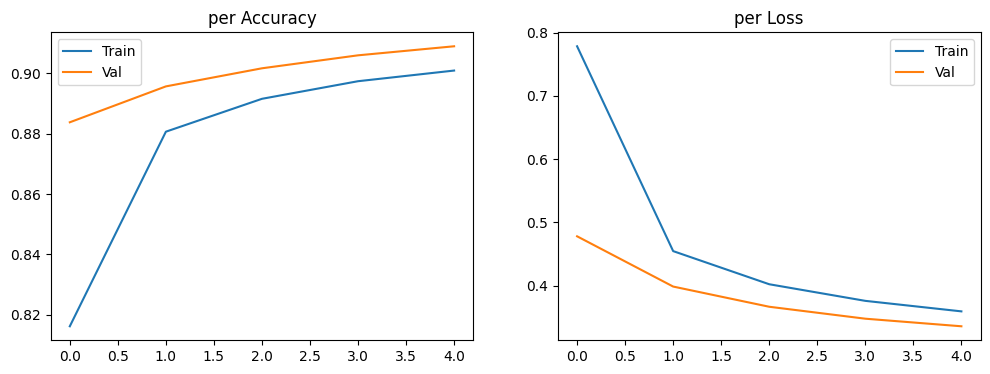

In [23]:
plot_training(history_per,"per")

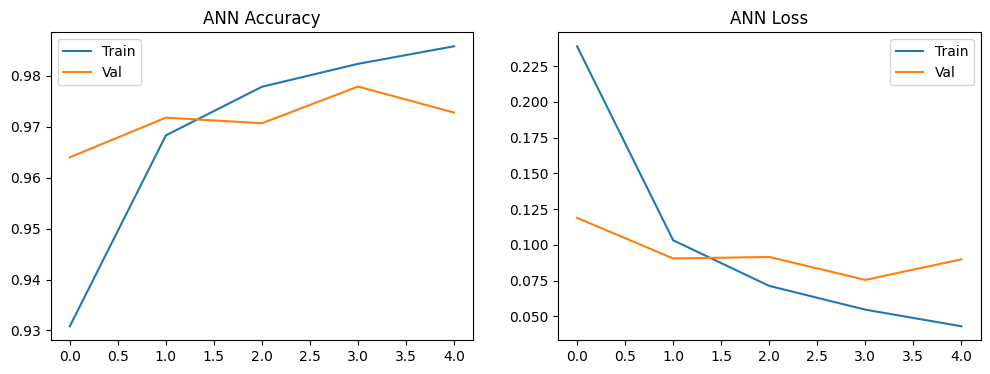

In [24]:
plot_training(history_ann,"ANN")

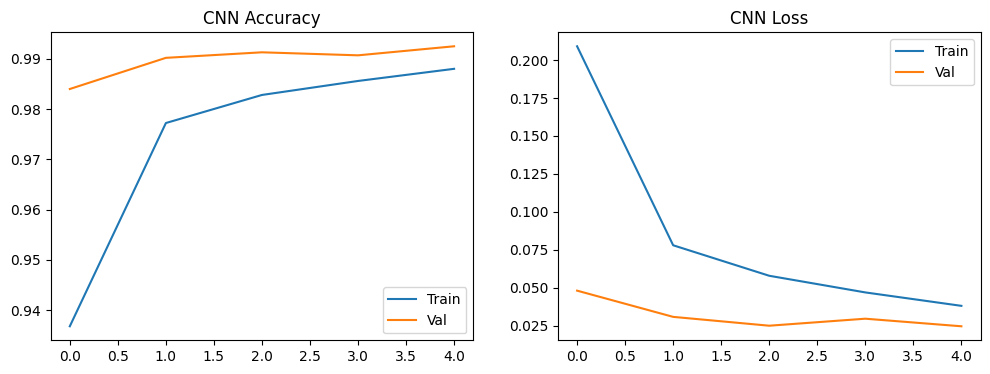

In [25]:
plot_training(history_cnn,"CNN")

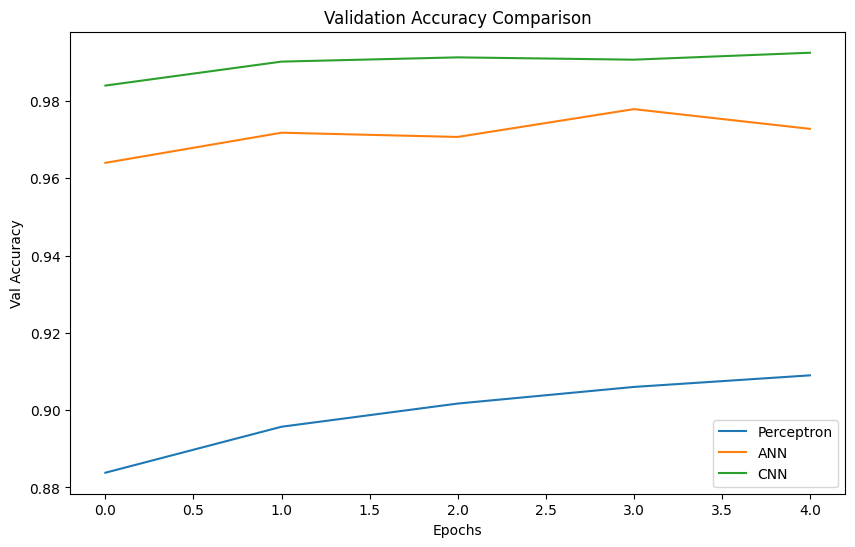

In [26]:
plt.figure(figsize=(10,6))
plt.plot(history_per.history['val_accuracy'], label="Perceptron")
plt.plot(history_ann.history['val_accuracy'], label="ANN")
plt.plot(history_cnn.history['val_accuracy'], label="CNN")
plt. title("Validation Accuracy Comparison")
plt.xlabel("Epochs")
plt.ylabel("Val Accuracy")
plt. legend()
plt. show()


In [27]:
def show_side_by_side(models, model_names, X, X_cnn, y_true, n=5):
    idxs = np.random.choice(len(X), n, replace=False)
    plt.figure(figsize=(15, 6))
    for i, idx in enumerate(idxs):
        plt.subplot(2, n, i+1)
        plt.imshow(X[idx].reshape(28, 28),cmap="gray")
        plt.axis("off")
        plt.title(f"True: {y_true[idx] }")
        preds = [np.argmax(model.predict(X_cnn[idx].reshape(1, 28, 28, 1) if name == "CNN" else X[idx]. reshape(1, 28, 28) ) )for model, name in zip(models, model_names) ]
        plt.subplot(2, n, n+i+1)
        plt.axis("off")
        plt.title("\n".join(f"{n}: {p}" for n, p in zip(model_names, preds) ))
    plt.tight_layout()
    plt.show()


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 112ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━

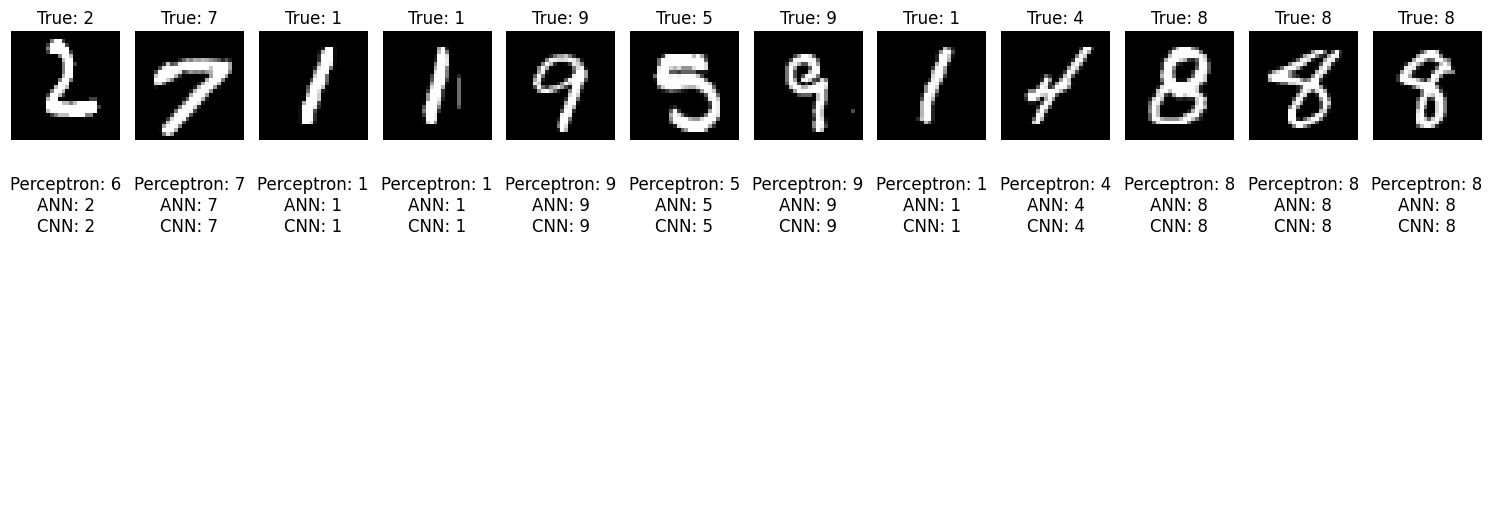

In [31]:
show_side_by_side([per, ann, cnn], ["Perceptron", "ANN", "CNN"],X_test_img, X_test_cnn, y_test,12)